#  Resume Data Cleaning & Exploratory Data Analysis (EDA)

##  Project Overview

This notebook performs data cleaning and exploratory data analysis (EDA) on a resume dataset containing information such as occupation, name, email, phone number, location, skills, experience, education, and other details.

The primary objective of this process is to ensure data quality, validate important fields, standardize formats, remove inconsistencies, and extract meaningful insights about candidate distribution across locations, occupations, and skills.

---

##  Data Cleaning Steps Performed

The following cleaning operations are applied to improve data reliability and consistency:

---

### 1️ Data Loading

The dataset is loaded into a pandas DataFrame using `read_csv()` to begin preprocessing and analysis.

Initial checks performed include:

- Dataset shape verification  
- Preview of first few rows  
- Dataset structure inspection using `info()`  
- Missing value summary  
- Duplicate record detection  

These steps help understand the dataset before applying cleaning operations.

---

### 2️ Handling Missing Name Values

Rows where the **name** column contains NULL values are identified and removed, since a resume without a name is considered invalid.

This ensures that every record represents a valid individual.

---

### 3️ Removing Duplicate Rows

Duplicate rows are identified and removed to prevent repeated entries and maintain data uniqueness.

This helps:

- Avoid duplicate resume records  
- Prevent biased frequency counts  
- Improve overall data integrity  

---

### 4️ Creating Unique Resume Identifier

A sequential **resume_id** column is created to uniquely identify each cleaned record.

This helps:

- Track individual records  
- Debug issues  
- Maintain consistent row identification  

---

### 5️ Dropping Fully Empty Rows

Completely empty rows are removed to eliminate irrelevant or blank records.

This ensures that no fully empty records remain in the dataset.

---

### 6️ Standardizing Column Names

Column names are cleaned and standardized to maintain consistency.

Operations applied:

- Remove extra spaces  
- Convert column names to lowercase  
- Replace spaces with underscores  

This ensures consistent referencing of column names throughout the notebook.

---

### 7️ Email Cleaning and Validation

Email addresses are cleaned and validated using regular expressions to ensure they follow a standard format.

**Expected format:**

name@example.com  

Cleaning steps include:

- Removing extra spaces  
- Removing accidental leading characters  
- Extracting valid email structure  
- Standardizing formatting  

Validation ensures:

- No spaces  
- Proper domain structure  
- Valid email syntax  

Invalid emails are flagged for further inspection.

---

### 8️ Phone Number Formatting and Validation

Phone numbers are cleaned and standardized into a consistent format.

**Standard format used:**

(XXX) XXX-XXXX  

Cleaning steps include:

- Removing leading characters  
- Extracting numeric digits  
- Keeping the last 10 digits  
- Formatting into structured phone pattern  

Phone numbers are validated using regular expressions to ensure correct structure.

Invalid phone entries are flagged for further inspection.

---

### 9️ Skills Cleaning and Processing

The `skills` column contains comma-separated values.

Example:

Python, SQL, Excel  

The following steps are applied:

- Split skills using commas  
- Remove extra spaces  
- Convert skills to lowercase  
- Store cleaned skills as a list  
- Calculate the number of skills per candidate  

This enables accurate skill-level analysis.

After processing, skills are converted back into comma-separated format for storage.

---

## Exploratory Data Analysis (EDA)

After cleaning the dataset, exploratory analysis is performed to understand key trends and distributions.

---

###  Location and City Analysis

Location values often contain full address information.

To improve analysis:

- City names are extracted from location strings  
- Missing city values are removed  
- Frequency counts of cities are calculated  

This helps identify:

- Cities with the highest number of candidates  
- Geographic distribution patterns  

A **bar chart** is created to visualize top cities.

---

### 🧑‍💼 Occupation Analysis

The most common occupations are identified using frequency counts.

This helps understand:

- Role distribution  
- Most represented job types  
- Workforce composition trends  

---

### 🛠️ Skill Analysis

Skills from all candidates are aggregated and counted to identify:

- Most common skills  
- Skill demand patterns  
- Skill distribution across resumes  

Steps performed:

- Combine all skills into one list  
- Count occurrences of each skill  
- Sort skills in descending order  
- Identify top skills  

A **bar chart** is generated to visualize the most frequently occurring skills.

---

### 📊 Skill Count Distribution

The number of skills per candidate is calculated.

This helps understand:

- Skill density per resume  
- Candidate skill variability  
- Distribution of expertise levels  

---

##  Final Output

After cleaning and analysis:

- Temporary helper columns (such as `skills_list`) are removed  
- Skills remain stored as comma-separated values  
- A unique `resume_id` column is maintained  
- Phone numbers are standardized  
- Emails are validated  
- City-level location data is created  

The cleaned dataset is exported as:

**`cleaned_data.csv`**

This dataset is now:

✔ Clean  
✔ Deduplicated  
✔ Standardized  
✔ Email-validated  
✔ Phone-formatted  
✔ Skills-processed  
✔ City-extracted  
✔ Ready for database ingestion  
✔ Suitable for further analysis and visualization  




In [60]:
# STEP 1 — IMPORT LIBRARIES
# =====================================

import pandas as pd
import numpy as np
import re

# Display full columns
pd.set_option("display.max_columns", None)


In [61]:
# STEP 2 — LOAD DATA
# =====================================

# Replace filename later
df = pd.read_csv("master_resumes_cleaned.csv")

print("Shape of dataset:", df.shape)

# Preview data
print("\nFirst 5 rows:")
print(df.head())



Shape of dataset: (299, 9)

First 5 rows:
   occupation            name                       email            phone_no  \
0  Accountant  Jessica Claire  B resumesample@e-ample.com   (555)4 432-1 1000   
1  Accountant  Jessica Claire    resumesample@example.com    C (555) 432-1000   
2  Accountant  Jessica Claire    resumesampledexample.com     (555)4 432-1000   
3  Accountant  Jessica Claire     resumsample@e-ample.com  C (555) 4 432-1000   
4  Accountant  Jessica Claire    resumesample@example.com      (555) 432-1000   

                                     location  \
0  Montgomery Street, San Francisco, CA 94105   
1  Montgomery Street, San Francisco, CA 94105   
2  Montgomery Street, San Francisco, CA 94105   
3  Montgomery Street, San Francisco, CA 94105   
4  Montgomery Street, San Francisco, CA 94105   

                                              skills  \
0  accounting, Accounts Payable, ADP Payroll, ad,...   
1  Payroll Management, Teledyne Technologies, Acc...   
2  Accou

In [62]:
# STEP 3 — BASIC EDA
# =====================================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


print("Duplicates before cleaning:",
      df.duplicated().sum())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   occupation     299 non-null    object
 1   name           298 non-null    object
 2   email          266 non-null    object
 3   phone_no       272 non-null    object
 4   location       258 non-null    object
 5   skills         251 non-null    object
 6   experience     298 non-null    object
 7   education      242 non-null    object
 8   other_details  265 non-null    object
dtypes: object(9)
memory usage: 21.2+ KB
None

Missing Values:
occupation        0
name              1
email            33
phone_no         27
location         41
skills           48
experience        1
education        57
other_details    34
dtype: int64
Duplicates before cleaning: 0


In [63]:
# Rows where name is null
null_name_rows = df[df["name"].isnull()]

print("Rows where name is NULL:")
print(null_name_rows)

Rows where name is NULL:
    occupation name email phone_no location skills  \
153  Education  NaN   NaN      NaN      NaN    NaN   

                                            experience  \
153  Student Teaching Baltimore Public School Syste...   

                                             education  \
153  Bachelor of Arts in Elementary Education Illin...   

                                         other_details  
153  Teacher certification for Elementary Education...  


In [64]:
# Drop rows where name is NULL
df = df[df["name"].notnull()]

print("Rows with NULL names dropped.")

print("New shape of dataset:", df.shape)

Rows with NULL names dropped.
New shape of dataset: (298, 9)


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

#add id column
df["resume_id"] = range(1, len(df) + 1)

In [ ]:
# STEP 4 — DROP EMPTY ROWS
# =====================================

df = df.dropna(how="all")

print("\nShape after dropping empty rows:", df.shape)




Shape after dropping empty rows: (298, 10)


In [67]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['occupation', 'name', 'email', 'phone_no', 'location', 'skills',
       'experience', 'education', 'other_details', 'resume_id'],
      dtype='object')


In [68]:
# =====================================
# STEP 6 — ENSURE DATA TYPES
# =====================================

string_columns = [
    "occupation",
    "name",
    "location",
    "experience",
    "education",
    "other_details"
]

df[string_columns] = df[string_columns].astype(str)



In [ ]:
email_pattern = r'^[A-Za-z0-9._-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'

df["email_valid"] = df["email"].apply(
    lambda x: bool(re.match(email_pattern, str(x)))
)

print("\nInvalid Emails:")
print(df[df["email_valid"] == False][["resume_id", "email"]])



Invalid Emails:
     resume_id                        email
0            1   B resumesample@e-ample.com
2            3     resumesampledexample.com
9           10  resumesampleGe Bexample.com
13          14                          NaN
16          17   a resumesample@example.com
..         ...                          ...
280        280                          NaN
286        286   A resumesample@example.com
288        288        resnune-amp@eumplecom
289        289       resume-ample@eamplecom
291        291                          NaN

[84 rows x 2 columns]


In [70]:

def clean_email(email):

    if pd.isna(email):
        return email

    email = str(email).strip()

    # Remove spaces
    email = email.replace(" ", "")

    # Remove hyphens if required
    email = email.replace("-", "")

    # Extract valid email
    match = re.search(
        r'[A-Za-z0-9._]+@[A-Za-z0-9]+\.[A-Za-z]{2,}',
        email
    )

    if match:
        cleaned = match.group(0)

        # Remove accidental leading capital letter
        if (
            len(cleaned) > 1
            and cleaned[0].isupper()
            and cleaned[1].islower()
        ):
            cleaned = cleaned[1:]

        return cleaned

    return email


df["email"] = df["email"].apply(clean_email)

In [71]:
email_pattern = r'^[A-Za-z0-9._]+@[A-Za-z0-9]+\.[A-Za-z]{2,}$'

df["email_valid"] = df["email"].apply(
    lambda x: bool(re.match(email_pattern, str(x)))
)

In [72]:
print(df["email"] )

0        resumesample@eample.com
1       resumesample@example.com
2       resumesampledexample.com
3         resumsample@eample.com
4       resumesample@example.com
                 ...            
294         christarki@gmail.com
295    hello@reallygreatsite.com
296              email@email.com
297    allentchaudhari@gmail.com
298           john.doc@gmail.com
Name: email, Length: 298, dtype: object


In [ ]:

def format_phone(phone):

    if pd.isna(phone):
        return phone

    phone = str(phone)

    # Remove leading letters 
    phone = re.sub(r'^[A-Za-z]+\s*', '', phone)

    # Extract digits only
    digits = re.sub(r'\D', '', phone)

    # Keep last 10 digits
    if len(digits) >= 10:

        digits = digits[-10:]

        # Format into (XXX) XXX-XXXX
        formatted = f"({digits[:3]}) {digits[3:6]}-{digits[6:]}"

        return formatted

    # If not enough digits → return NaN
    return pd.NA


# Apply formatting
df["phone_no"] = df["phone_no"].apply(format_phone)

In [74]:
phone_pattern = r'^\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}$'

df["phone_valid"] = df["phone_no"].apply(
    lambda x: bool(re.match(phone_pattern, str(x)))
)

print("\nInvalid Phone Numbers:")
print(df[df["phone_valid"] == False][["resume_id", "phone_no"]])


Invalid Phone Numbers:
     resume_id phone_no
12          13      NaN
23          24     <NA>
25          26      NaN
35          36      NaN
63          64      NaN
65          66     <NA>
68          69      NaN
73          74     <NA>
76          77      NaN
81          82      NaN
88          89     <NA>
110        111     <NA>
115        116      NaN
118        119     <NA>
123        124      NaN
124        125     <NA>
132        133     <NA>
137        138      NaN
138        139      NaN
155        155     <NA>
165        165      NaN
166        166      NaN
170        170     <NA>
174        174     <NA>
176        176     <NA>
178        178      NaN
181        181     <NA>
182        182      NaN
185        185     <NA>
188        188      NaN
197        197     <NA>
198        198      NaN
203        203     <NA>
208        208      NaN
222        222     <NA>
230        230     <NA>
236        236      NaN
239        239      NaN
244        244      NaN
248        248  

In [77]:
# Convert to list
df["skills_list"] = df["skills"].apply(
    lambda x: [
        s.strip().lower()
        for s in str(x).split(",")
        if s.strip() != ""
    ]
)

# Count skills
df["skill_count"] = df["skills_list"].apply(len)



In [78]:
# STEP 10 — BASIC FREQUENCY ANALYSIS
# =====================================

print("\nTop Occupations:")
print(df["occupation"].value_counts())

print("\nTop Locations:")
print(df["location"].value_counts())

print("\nSkill Count Distribution:")
print(df["skill_count"].value_counts())


Top Occupations:
occupation
Accountant                   7
SQL Developer                7
Electrical Engineer          7
ETL Developer                7
Finance                      7
Food & Beverages             7
Health & Fitness             7
Human Resources              7
Information Technology       7
Java Developer               7
Management                   7
Mechanical Engineer          7
Network Security Engineer    7
Operations Manager           7
PMO                          7
Public Relations             7
Testing                      7
React Developer              7
Sales                        7
Advocate                     7
DotNet Developer             7
Digital Media                7
Blockchain                   7
Agriculture                  7
Apparel                      7
Architect                    7
Arts                         7
Automobile                   7
Aviation                     7
Banking                      7
BPO                          7
DevOps Eng

In [79]:
# =====================================
# LOCATION FREQUENCY
# =====================================

location_counts = df["location"].value_counts()

print("\nTop Locations:")
print(location_counts.head(10))


Top Locations:
location
nan                                           40
Montgomery Street, San Francisco, CA 94105    34
Alabama                                        9
173 7 Marshville Road, Alabama                 8
1001 Montgomery St. 10th Floor                 6
100 Montgomery St. 10th Floor                  5
Detroit, MI                                    4
1737 Marshville Road, Alabama                  4
Montgomery St. 10th Floor                      4
100N Montgomery St. 10th Floor                 3
Name: count, dtype: int64


In [83]:
# Extract city (usually second part after comma)

df["city"] = df["location"].dropna()

df["city"] = (
    df["location"]
    .str.split(",")
    .str[1]      # city part
)

# Clean city names
df["city"] = (
    df["city"]
    .str.strip()
)

# Remove missing values
clean_city = df["city"].dropna()

# Get top cities
top_cities = clean_city.value_counts().head(10)

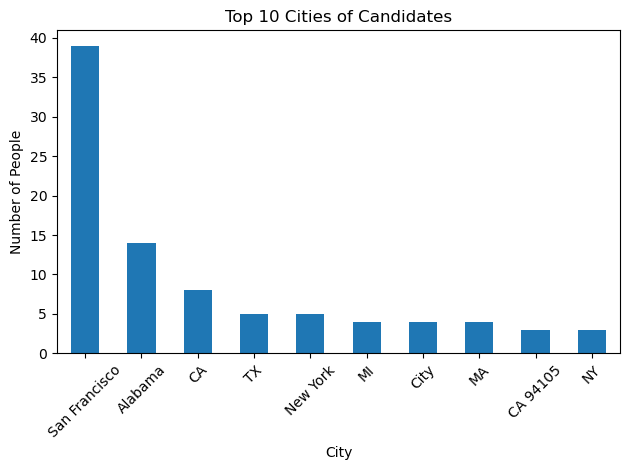

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

top_cities.plot(kind="bar")

plt.title("Top 10 Cities of Candidates")

plt.xlabel("City")

plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [85]:
from collections import Counter

# Combine all skills into one list
all_skills = []

for skills in df["skills_list"]:
    all_skills.extend(skills)

# Count skills
skill_counts = Counter(all_skills)

# Convert to dataframe
skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "count"]
)

# Sort descending
skill_df = skill_df.sort_values(
    by="count",
    ascending=False
)

print("\nTop Skills:")
print(skill_df.head(10))


Top Skills:
                  skill  count
136                 nan     47
911              python     17
249    customer service     16
500                java     16
462  project management     15
905                 sql     15
37     microsoft office     14
957          javascript     14
991               mysql     13
157     time management     12


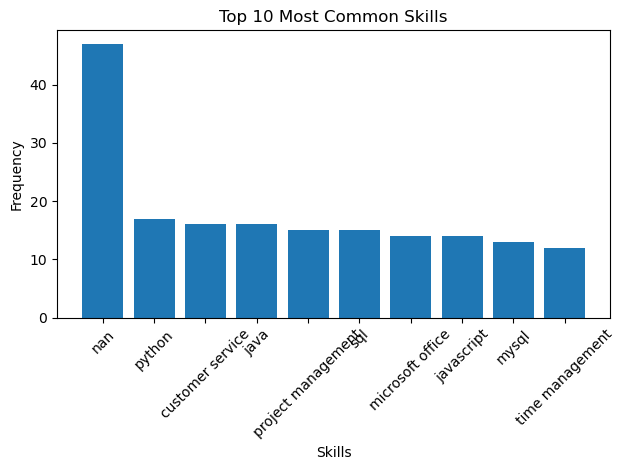

In [86]:
# Top 10 skills
top_skills = skill_df.head(10)

plt.figure()

plt.bar(
    top_skills["skill"],
    top_skills["count"]
)

plt.title("Top 10 Most Common Skills")

plt.xlabel("Skills")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [87]:
# Convert back to string
df["skills"] = df["skills_list"].apply(
    lambda x: ", ".join(x)
)

# Drop helper column
df.drop(columns=["skills_list"], inplace=True)

In [88]:
print("\nCleaned Data (First 5 Rows):")
print(df.head())


Cleaned Data (First 5 Rows):
   occupation            name                     email        phone_no  \
0  Accountant  Jessica Claire   resumesample@eample.com  (544) 321-1000   
1  Accountant  Jessica Claire  resumesample@example.com  (555) 432-1000   
2  Accountant  Jessica Claire  resumesampledexample.com  (554) 432-1000   
3  Accountant  Jessica Claire    resumsample@eample.com  (554) 432-1000   
4  Accountant  Jessica Claire  resumesample@example.com  (555) 432-1000   

                                     location  \
0  Montgomery Street, San Francisco, CA 94105   
1  Montgomery Street, San Francisco, CA 94105   
2  Montgomery Street, San Francisco, CA 94105   
3  Montgomery Street, San Francisco, CA 94105   
4  Montgomery Street, San Francisco, CA 94105   

                                              skills  \
0  accounting, accounts payable, adp payroll, ad,...   
1  payroll management, teledyne technologies, acc...   
2  account reconciliation specialist, superior at...   


In [76]:

# =====================================
# STEP 13 — SAVE CLEANED DATA
# =====================================

df.to_csv("cleaned_data.csv", index=False)

print("\nCleaned data saved successfully!")


Cleaned data saved successfully!
